# Zadanie domowe

W przypadku obrazów w odcieniach szarości pojedynczy piksel z zakresu [0; 255] reprezentowany jest jako 8-bitowa liczba bez znaku.
Pewnym rozszerzeniem analizy sposobu reprezentacji obrazu może być następujący eksperyment.
Załóżmy, że z każdego z 8 bitów możemy stworzyć pojedynczy obraz binarny (ang. _bit-plane slicing_).
Dla obrazka _100zloty.jpg_ (https://raw.githubusercontent.com/vision-agh/poc_sw/master/02_Point/100zloty.jpg) stwórz 8 obrazów, z których każdy powinien zawierać jedną płaszczyznę bitową.
Podpowiedź $-$ warto sprawdzić, jak realizuje się bitowe operacje logiczne.
Zastosowanie takiej dekompozycji obrazu pozwala na analizę ,,ważności'' poszczególnych bitów.
Jest to użyteczne w kwantyzacji, ale także w kompresji.

W drugim etapie zadania proszę spróbować odtworzyć obraz oryginalny z mniejszej liczby obrazów binarnych.
Warto zacząć od dwóch najbardziej znaczących bitów, a później dodawać kolejne.
Należy utworzyć co najmniej trzy wersje zrekonstruowanych obrazów.
Podpowiedź $-$ rekonstrukcja obrazu to mnożenie przez odpowiednią potęgę liczby 2 (przesunięcie bitowe) oraz dodawanie.

--2025-03-12 18:48:08--  https://raw.githubusercontent.com/vision-agh/poc_sw/master/02_Point/100zloty.jpg
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.108.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 997750 (974K) [image/jpeg]
Saving to: '100zloty.jpg'

     0K .......... .......... .......... .......... ..........  5% 1,13M 1s
    50K .......... .......... .......... .......... .......... 10%  756K 1s
   100K .......... .......... .......... .......... .......... 15% 1,69M 1s
   150K .......... .......... .......... .......... .......... 20% 8,46M 1s
   200K .......... .......... .......... .......... .......... 25% 1,47M 1s
   250K .......... .......... .......... .......... .......... 30% 2,21M 0s
   300K .......... .......... .......... .......... .......... 35% 2,90M 0s
   350K .......... .........

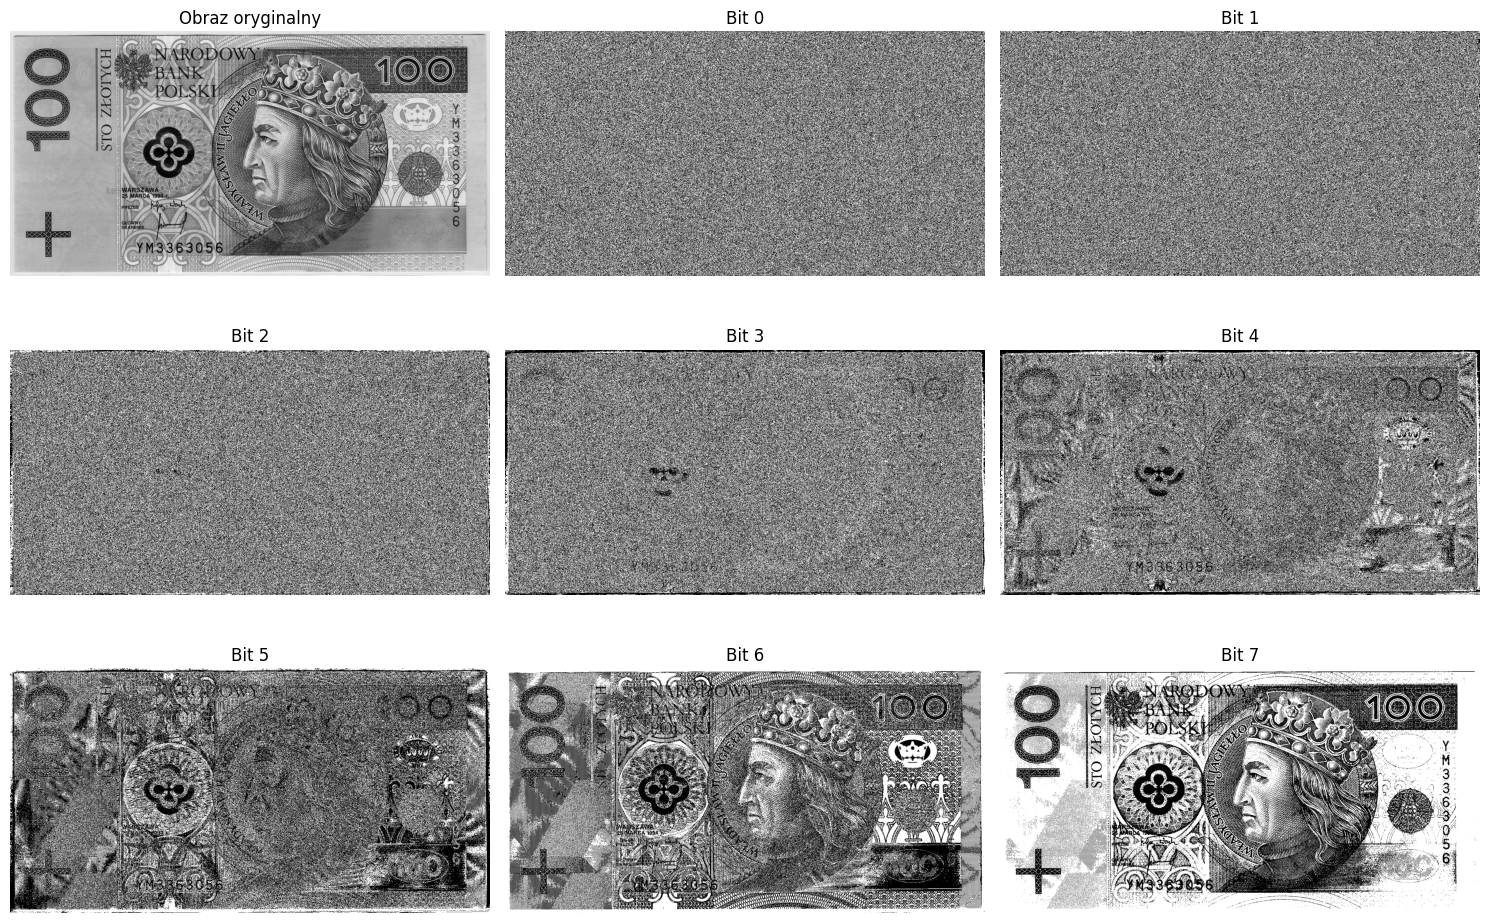

Rekonstrukcja z 2 najbardziej znaczące bity (7-6):
  PSNR: 17.59 dB
  Procent użytych bitów: 25.0%
Rekonstrukcja z 4 najbardziej znaczące bity (7-4):
  PSNR: 29.29 dB
  Procent użytych bitów: 50.0%
Rekonstrukcja z 6 najbardziej znaczących bitów (7-2):
  PSNR: 42.70 dB
  Procent użytych bitów: 75.0%


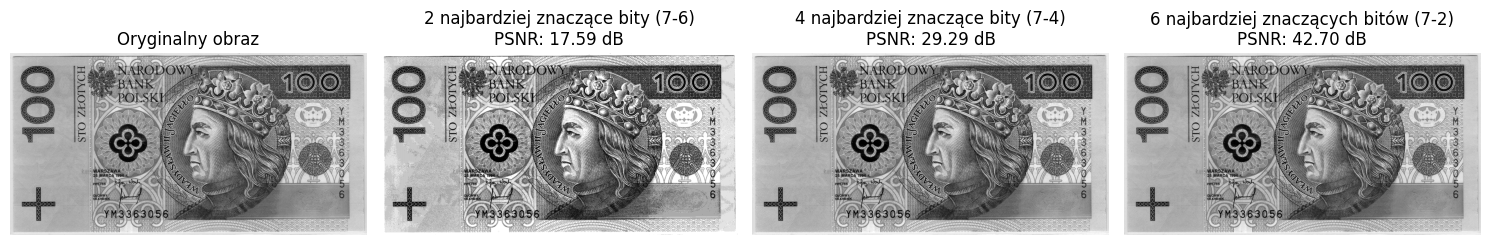

Rekonstrukcja z Bity 7 i 0:
  PSNR: 11.22 dB
  Procent użytych bitów: 25.0%
Rekonstrukcja z Bity 7 i 3:
  PSNR: 11.59 dB
  Procent użytych bitów: 25.0%
Rekonstrukcja z Bity 6, 4 i 2:
  PSNR: 6.56 dB
  Procent użytych bitów: 37.5%


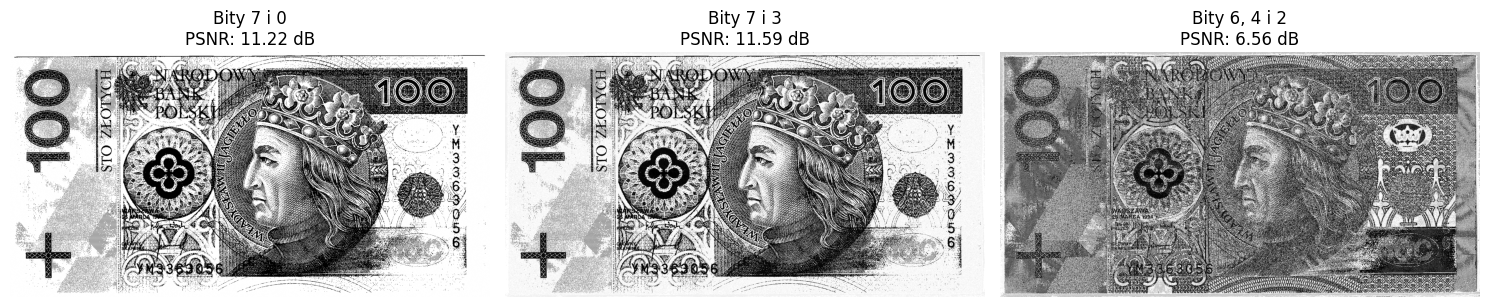

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os
import sys

if not os.path.exists("100zloty.jpg"):
    !wget https://raw.githubusercontent.com/vision-agh/poc_sw/master/02_Point/100zloty.jpg

img = cv2.imread("100zloty.jpg")
if img is None:
    print("Nie udało się wczytać obrazu. Sprawdź czy plik istnieje.")
    sys.exit(1)

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img_gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)

def extract_bit_planes(img_gray):
    bit_planes = []
    for i in range(8):
        mask = 1 << i
        bit_plane = np.bitwise_and(img_gray, mask)
        bit_plane_normalized = np.where(bit_plane > 0, 255, 0).astype(np.uint8)
        bit_planes.append({
            'bit': i,
            'plane': bit_plane,
            'normalized': bit_plane_normalized
        })
    return bit_planes

def reconstruct_image(bit_planes, selected_bits):
    reconstructed = np.zeros_like(bit_planes[0]['plane'])
    for bit in selected_bits:
        shifted_bit = (bit_planes[bit]['plane'] > 0).astype(np.uint8) * (1 << bit)
        reconstructed = cv2.add(reconstructed, shifted_bit)
    return reconstructed

def calculate_psnr(original, reconstructed):
    original = original.astype(np.float64)
    reconstructed = reconstructed.astype(np.float64)
    mse = np.mean((original - reconstructed) ** 2)
    if mse == 0:
        return float('inf')
    max_pixel = 255.0
    return 20 * np.log10(max_pixel / np.sqrt(mse))

bit_planes = extract_bit_planes(img_gray)

plt.figure(figsize=(15, 10))
plt.subplot(3, 3, 1)
plt.title("Obraz oryginalny")
plt.imshow(img_gray, cmap='gray')
plt.axis('off')
for i, plane in enumerate(bit_planes):
    plt.subplot(3, 3, i + 2)
    plt.title(f"Bit {plane['bit']}")
    plt.imshow(plane['normalized'], cmap='gray')
    plt.axis('off')
plt.tight_layout()
plt.savefig("bit_planes.png")
plt.show()

reconstruction_sets = [
    {'bits': [7, 6], 'title': '2 najbardziej znaczące bity (7-6)'},
    {'bits': [7, 6, 5, 4], 'title': '4 najbardziej znaczące bity (7-4)'},
    {'bits': [7, 6, 5, 4, 3, 2], 'title': '6 najbardziej znaczących bitów (7-2)'}
]

plt.figure(figsize=(15, 5))
plt.subplot(1, 4, 1)
plt.title("Oryginalny obraz")
plt.imshow(img_gray, cmap='gray')
plt.axis('off')

for i, rec_set in enumerate(reconstruction_sets):
    reconstructed = reconstruct_image(bit_planes, rec_set['bits'])
    psnr = calculate_psnr(img_gray, reconstructed)
    plt.subplot(1, 4, i + 2)
    plt.title(f"{rec_set['title']}\nPSNR: {psnr:.2f} dB")
    plt.imshow(reconstructed, cmap='gray')
    plt.axis('off')
    filename = f"reconstruction_{'_'.join(str(b) for b in rec_set['bits'])}.png"
    cv2.imwrite(filename, reconstructed)
    print(f"Rekonstrukcja z {rec_set['title']}:")
    print(f"  PSNR: {psnr:.2f} dB")
    print(f"  Procent użytych bitów: {len(rec_set['bits'])/8*100:.1f}%")

plt.tight_layout()
plt.savefig("reconstructions.png")
plt.show()

additional_sets = [
    {'bits': [7, 0], 'title': 'Bity 7 i 0'},
    {'bits': [7, 3], 'title': 'Bity 7 i 3'},
    {'bits': [6, 4, 2], 'title': 'Bity 6, 4 i 2'}
]

plt.figure(figsize=(15, 5))
for i, rec_set in enumerate(additional_sets):
    reconstructed = reconstruct_image(bit_planes, rec_set['bits'])
    psnr = calculate_psnr(img_gray, reconstructed)
    plt.subplot(1, 3, i + 1)
    plt.title(f"{rec_set['title']}\nPSNR: {psnr:.2f} dB")
    plt.imshow(reconstructed, cmap='gray')
    plt.axis('off')
    filename = f"reconstruction_{'_'.join(str(b) for b in rec_set['bits'])}.png"
    cv2.imwrite(filename, reconstructed)
    print(f"Rekonstrukcja z {rec_set['title']}:")
    print(f"  PSNR: {psnr:.2f} dB")
    print(f"  Procent użytych bitów: {len(rec_set['bits'])/8*100:.1f}%")

plt.tight_layout()
plt.savefig("additional_reconstructions.png")
plt.show()